In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from plotly import express as px
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import plotly.io as pio
pio.renderers.default = "png" 

In [2]:
data = pd.read_csv("pakistan_ecommerce.csv")
data

/var/folders/qx/t5660_gn1639zk2tzf5bgdbw0000gn/T/ipykernel_48924/3381553910.py:1: DtypeWarning:

Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.



,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,07/01/2016,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,\N,...,cod,07/01/2016,#REF!,"1,950",2016,7,2016-7,Jul-16,FY17,1.0
1,211133,canceled,07/01/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,\N,...,cod,07/01/2016,Gross,240,2016,7,2016-7,Jul-16,FY17,2.0
2,211134,canceled,07/01/2016,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,\N,...,cod,07/01/2016,Gross,"2,450",2016,7,2016-7,Jul-16,FY17,3.0
3,211135,complete,07/01/2016,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,07/01/2016,Net,360,2016,7,2016-7,Jul-16,FY17,4.0
4,211136,order_refunded,07/01/2016,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,\N,...,cod,07/01/2016,Valid,"1,110",2016,7,2016-7,Jul-16,FY17,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584519,905204,cod,8/28/2018,WOFSCE5AE00357AECDE,699.0,1,849.0,100562385,Women's Fashion,NaN,...,cod,8/28/2018,Valid,699,2018,8,2018-8,Aug-18,FY19,115320.0
584520,905205,processing,8/28/2018,MATHUA5AF70A7D1E50A,35599.0,1,35899.0,100562386,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"35,599",2018,8,2018-8,Aug-18,FY19,115326.0
584521,905206,processing,8/28/2018,MATSAM5B6D7208C6D30,129999.0,2,652178.0,100562387,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"259,998",2018,8,2018-7,Aug-18,FY19,113474.0
584522,905207,processing,8/28/2018,MATSAM5B1509B4696EA,87300.0,2,652178.0,100562387,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"174,600",2018,8,2018-7,Aug-18,FY19,113474.0


In [3]:
data.shape

(584524, 21)

In [4]:
data.columns.unique

<bound method Index.unique of Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID'],
      dtype='object')>

## Keeping Cash on Delivery rows only

In [5]:
data = data[data['payment_method'].isin(['cod', 'cashatdoorstep'])]

In [6]:
data.shape

(272692, 21)

## Merging Cash on Delivery and cashatdoorstep

In [7]:
data['payment_method'] = 'COD' 

/var/folders/qx/t5660_gn1639zk2tzf5bgdbw0000gn/T/ipykernel_48924/889277788.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Getting line order total and dropping Grand Total

In [8]:
data['item_total'] = data['price'] * data['qty_ordered']
data = data.drop(columns=['grand_total'])

/var/folders/qx/t5660_gn1639zk2tzf5bgdbw0000gn/T/ipykernel_48924/4208464146.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Evaluating Unique Orders and Unique Customers

In [9]:
print(f"Total rows: {len(data)}")
print(f"Unique orders: {data['increment_id'].nunique()}")
print(f"Unique customers: {data['Customer ID'].nunique()}")

Total rows: 272692
Unique orders: 183093
Unique customers: 76076


# Dropping irrelevant columns

In [10]:
data = data.drop(columns=['item_id','payment_method', 'BI Status', ' MV ', 'sales_commission_code', 'FY', 'M-Y','increment_id'])

In [11]:
data.columns.unique

<bound method Index.unique of Index(['status', 'created_at', 'sku', 'price', 'qty_ordered',
       'category_name_1', 'discount_amount', 'Working Date', 'Year', 'Month',
       'Customer Since', 'Customer ID', 'item_total'],
      dtype='object')>

In [12]:
data.shape

(272692, 13)

# No of missing Values

In [13]:
data.isnull().sum()

status              14
created_at           0
sku                 20
price                0
qty_ordered          0
category_name_1    151
discount_amount      0
Working Date         0
Year                 0
Month                0
Customer Since       5
Customer ID          5
item_total           0
dtype: int64

In [14]:
data = data.dropna()

In [15]:
data.isnull().sum()

status             0
created_at         0
sku                0
price              0
qty_ordered        0
category_name_1    0
discount_amount    0
Working Date       0
Year               0
Month              0
Customer Since     0
Customer ID        0
item_total         0
dtype: int64

In [16]:
successful = ['complete', 'received', 'closed', 'paid']
unsuccessful = ['canceled', 'fraud']

data = data[data['status'].isin(successful + unsuccessful)]
data['status'] = data['status'].apply(lambda x: 'Successful' if x in successful else 'Cancelled')
data = data[data['category_name_1'] != r'\N']

In [17]:
print(data['status'].value_counts())

status
Successful    191144
Cancelled      20920
Name: count, dtype: int64


In [18]:
data.head() # can talk about class imbalance here

,status,created_at,sku,price,qty_ordered,category_name_1,discount_amount,Working Date,Year,Month,Customer Since,Customer ID,item_total
0,Successful,07/01/2016,kreations_YI 06-L,1950.0,1,Women's Fashion,0.0,07/01/2016,2016,7,2016-7,1.0,1950.0
1,Cancelled,07/01/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,Beauty & Grooming,0.0,07/01/2016,2016,7,2016-7,2.0,240.0
2,Cancelled,07/01/2016,Ego_UP0017-999-MR0,2450.0,1,Women's Fashion,0.0,07/01/2016,2016,7,2016-7,3.0,2450.0
3,Successful,07/01/2016,kcc_krone deal,360.0,1,Beauty & Grooming,300.0,07/01/2016,2016,7,2016-7,4.0,360.0
5,Cancelled,07/01/2016,UK_Namkino All In One 200 Gms,80.0,1,Soghaat,0.0,07/01/2016,2016,7,2016-7,6.0,80.0


In [19]:
data.shape

(212064, 13)

In [20]:
data.dtypes

status              object
created_at          object
sku                 object
price              float64
qty_ordered          int64
category_name_1     object
discount_amount    float64
Working Date        object
Year                 int64
Month                int64
Customer Since      object
Customer ID        float64
item_total         float64
dtype: object

In [21]:
# Feature engineering
data['created_at_dt'] = pd.to_datetime(data['created_at'], format='mixed', errors='coerce')
data['cust_since_dt'] = pd.to_datetime(data['Customer Since'], format='%Y-%m', errors='coerce')
data['day_of_week'] = data['created_at_dt'].dt.dayofweek
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
data['discount_pct'] = data['discount_amount'] / (data['item_total']) * 100
data['discount_pct'] = data['discount_pct'].clip(upper=100)
data['has_discount'] = (data['discount_amount'] > 0).astype(int)

In [22]:
data.shape

(212064, 19)

In [23]:
data.head()

,status,created_at,sku,price,qty_ordered,category_name_1,discount_amount,Working Date,Year,Month,Customer Since,Customer ID,item_total,created_at_dt,cust_since_dt,day_of_week,is_weekend,discount_pct,has_discount
0,Successful,07/01/2016,kreations_YI 06-L,1950.0,1,Women's Fashion,0.0,07/01/2016,2016,7,2016-7,1.0,1950.0,2016-07-01,2016-07-01,4,0,0.000000,0
1,Cancelled,07/01/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,Beauty & Grooming,0.0,07/01/2016,2016,7,2016-7,2.0,240.0,2016-07-01,2016-07-01,4,0,0.000000,0
2,Cancelled,07/01/2016,Ego_UP0017-999-MR0,2450.0,1,Women's Fashion,0.0,07/01/2016,2016,7,2016-7,3.0,2450.0,2016-07-01,2016-07-01,4,0,0.000000,0
3,Successful,07/01/2016,kcc_krone deal,360.0,1,Beauty & Grooming,300.0,07/01/2016,2016,7,2016-7,4.0,360.0,2016-07-01,2016-07-01,4,0,83.333333,1
5,Cancelled,07/01/2016,UK_Namkino All In One 200 Gms,80.0,1,Soghaat,0.0,07/01/2016,2016,7,2016-7,6.0,80.0,2016-07-01,2016-07-01,4,0,0.000000,0


In [24]:
# Price brackets for analysis
data = data[data['price'] >= 10]

data['price_bracket'] = pd.cut(data['price'],
    bins=[0, 500, 1000, 3000, 10000, float('inf')],
    labels=['PKR 0-500', 'PKR 500-1K', 'PKR 1K-3K', 'PKR 3K-10K', 'PKR 10K+'])
 
# Day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data['day_name'] = data['day_of_week'].map(dict(enumerate(day_names)))

In [25]:
data.head()

,status,created_at,sku,price,qty_ordered,category_name_1,discount_amount,Working Date,Year,Month,...,Customer ID,item_total,created_at_dt,cust_since_dt,day_of_week,is_weekend,discount_pct,has_discount,price_bracket,day_name
0,Successful,07/01/2016,kreations_YI 06-L,1950.0,1,Women's Fashion,0.0,07/01/2016,2016,7,...,1.0,1950.0,2016-07-01,2016-07-01,4,0,0.000000,0,PKR 1K-3K,Friday
1,Cancelled,07/01/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,Beauty & Grooming,0.0,07/01/2016,2016,7,...,2.0,240.0,2016-07-01,2016-07-01,4,0,0.000000,0,PKR 0-500,Friday
2,Cancelled,07/01/2016,Ego_UP0017-999-MR0,2450.0,1,Women's Fashion,0.0,07/01/2016,2016,7,...,3.0,2450.0,2016-07-01,2016-07-01,4,0,0.000000,0,PKR 1K-3K,Friday
3,Successful,07/01/2016,kcc_krone deal,360.0,1,Beauty & Grooming,300.0,07/01/2016,2016,7,...,4.0,360.0,2016-07-01,2016-07-01,4,0,83.333333,1,PKR 0-500,Friday
5,Cancelled,07/01/2016,UK_Namkino All In One 200 Gms,80.0,1,Soghaat,0.0,07/01/2016,2016,7,...,6.0,80.0,2016-07-01,2016-07-01,4,0,0.000000,0,PKR 0-500,Friday


# Dropping unneccesary columns

In [26]:
data = data.drop(columns=['created_at', 'Working Date', 'Customer Since', 'created_at_dt', 'cust_since_dt'])

In [27]:
data.shape

(210446, 16)

In [28]:
data.head()

,status,sku,price,qty_ordered,category_name_1,discount_amount,Year,Month,Customer ID,item_total,day_of_week,is_weekend,discount_pct,has_discount,price_bracket,day_name
0,Successful,kreations_YI 06-L,1950.0,1,Women's Fashion,0.0,2016,7,1.0,1950.0,4,0,0.000000,0,PKR 1K-3K,Friday
1,Cancelled,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,Beauty & Grooming,0.0,2016,7,2.0,240.0,4,0,0.000000,0,PKR 0-500,Friday
2,Cancelled,Ego_UP0017-999-MR0,2450.0,1,Women's Fashion,0.0,2016,7,3.0,2450.0,4,0,0.000000,0,PKR 1K-3K,Friday
3,Successful,kcc_krone deal,360.0,1,Beauty & Grooming,300.0,2016,7,4.0,360.0,4,0,83.333333,1,PKR 0-500,Friday
5,Cancelled,UK_Namkino All In One 200 Gms,80.0,1,Soghaat,0.0,2016,7,6.0,80.0,4,0,0.000000,0,PKR 0-500,Friday


# Exploratory Data Analysis

### Univariate Analysis

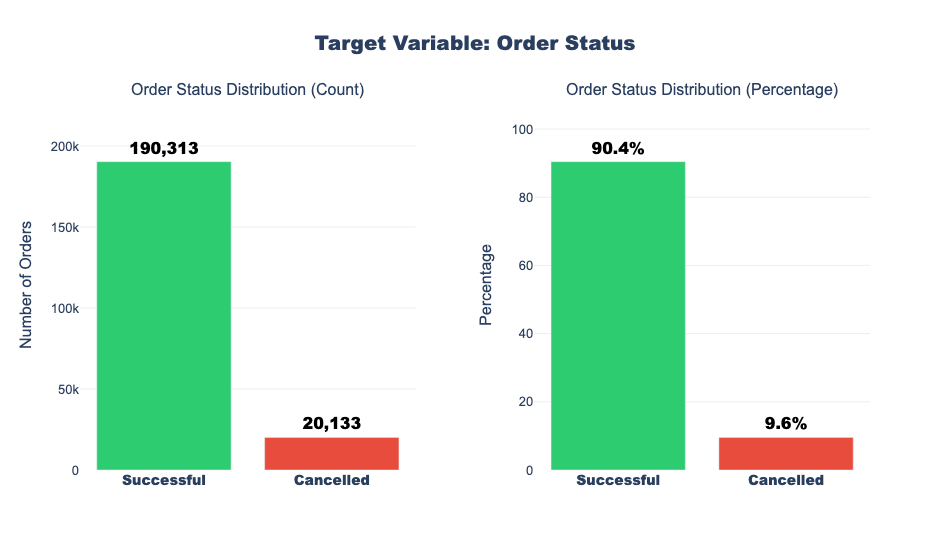

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

counts = data['status'].value_counts()
pcts = data['status'].value_counts(normalize=True) * 100
colors = ['#2ecc71', '#e74c3c']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Order Status Distribution (Count)',
                                    'Order Status Distribution (Percentage)'),
                    horizontal_spacing=0.15)

# Count plot
fig.add_trace(
    go.Bar(x=counts.index, y=counts.values, marker_color=colors,
           text=[f'{v:,}' for v in counts.values], textposition='outside',
           textfont=dict(size=16, color='black', family='Arial Black'),
           showlegend=False),
    row=1, col=1)

# Percentage plot
fig.add_trace(
    go.Bar(x=pcts.index, y=pcts.values, marker_color=colors,
           text=[f'{v:.1f}%' for v in pcts.values], textposition='outside',
           textfont=dict(size=16, color='black', family='Arial Black'),
           showlegend=False),
    row=1, col=2)

fig.update_layout(
    height=550, width=950,
    title_text='Target Variable: Order Status',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13))

# Give headroom so the text labels don't get clipped
fig.update_yaxes(title_text='Number of Orders', row=1, col=1,
                 range=[0, counts.max() * 1.2], gridcolor='#EEEEEE')
fig.update_yaxes(title_text='Percentage', row=1, col=2,
                 range=[0, pcts.max() * 1.2], gridcolor='#EEEEEE')

fig.update_xaxes(tickfont=dict(size=14, family='Arial Black'))

fig.show(renderer="png")

### Product Category

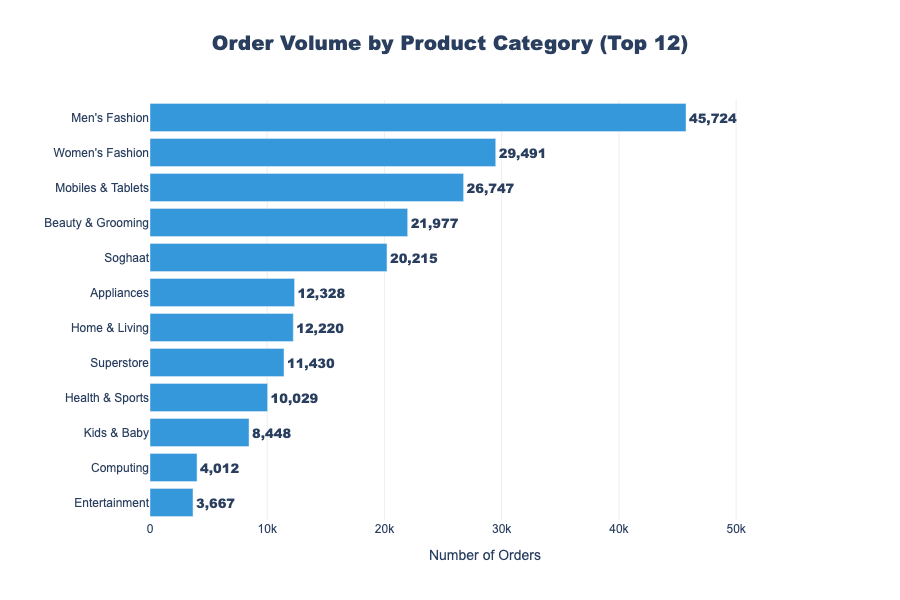

In [30]:
fig = go.Figure()

cat_counts = data['category_name_1'].value_counts().head(12)

fig.add_trace(
    go.Bar(y=cat_counts.index[::-1], x=cat_counts.values[::-1],
           orientation='h',
           marker_color='#3498db',
           text=[f'{v:,}' for v in cat_counts.values[::-1]],
           textposition='outside',
           textfont=dict(size=13, family='Arial Black')))

fig.update_layout(
    height=600, width=900,
    title_text='Order Volume by Product Category (Top 12)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, cat_counts.max() * 1.25]),
    yaxis=dict(tickfont=dict(size=12)),
    margin=dict(l=150))

fig.show()

### Price Distribution

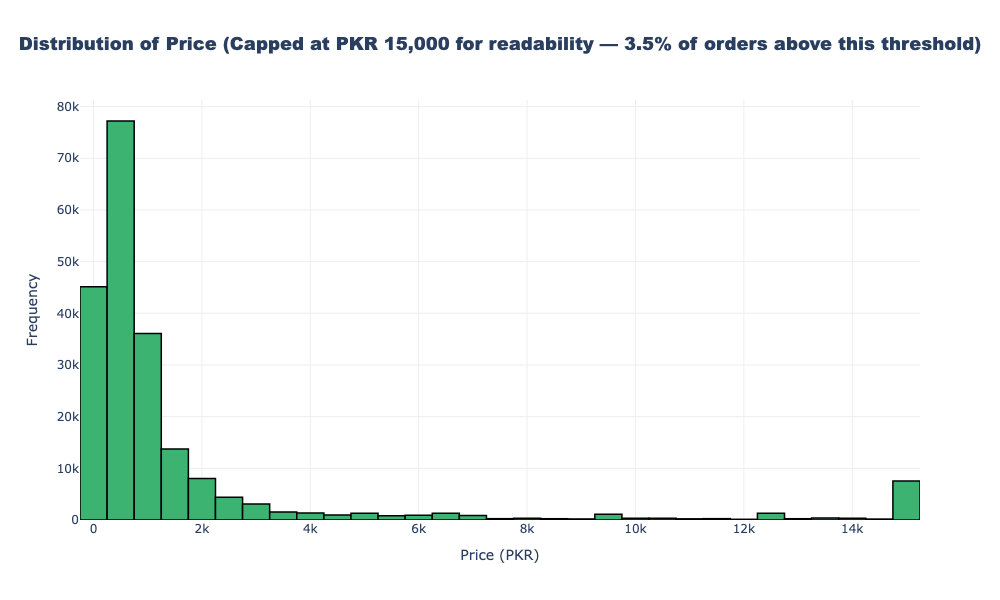

In [31]:
pct_above = (data['price'] > 15000).mean() * 100

fig = px.histogram(data, x=data['price'].clip(upper=15000),
                   height=600, width=1000,
                   title=f'Distribution of Price (Capped at PKR 15,000 for readability — {pct_above:.1f}% of orders above this threshold)',
                   labels={'x': 'Price (PKR)', 'count': 'Frequency'},
                   nbins=30)

fig.update_traces(
    marker_color='mediumseagreen',
    marker_line_color='black',
    marker_line_width=1.5)

fig.update_layout(
    title_x=0.5,
    title_font=dict(size=18, family='Arial Black'),
    plot_bgcolor='white',
    xaxis=dict(title='Price (PKR)', gridcolor='#EEEEEE'),
    yaxis=dict(title='Frequency', gridcolor='#EEEEEE'))

fig.show()

In [32]:
data[data['discount_pct']>=100]

,status,sku,price,qty_ordered,category_name_1,discount_amount,Year,Month,Customer ID,item_total,day_of_week,is_weekend,discount_pct,has_discount,price_bracket,day_name
1287,Successful,Turbo_100197,65.0,3,Home & Living,195.0,2016,7,514.0,195.0,1,0,100.0,1,PKR 0-500,Tuesday
1288,Successful,YC_ODD-CHP-DIP-PLT,142.0,1,Home & Living,142.0,2016,7,514.0,142.0,1,0,100.0,1,PKR 0-500,Tuesday
1289,Successful,tram_TT23080083,55.0,1,Home & Living,55.0,2016,7,514.0,55.0,1,0,100.0,1,PKR 0-500,Tuesday
1290,Successful,Turbo_100184,91.0,2,Home & Living,182.0,2016,7,514.0,182.0,1,0,100.0,1,PKR 0-500,Tuesday
1291,Successful,JBS_TAT-037,180.0,1,Home & Living,180.0,2016,7,514.0,180.0,1,0,100.0,1,PKR 0-500,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577990,Successful,HASKLI5A96E90769F95,40.0,1,Health & Sports,200.0,2018,8,114514.0,40.0,0,0,100.0,1,PKR 0-500,Monday
577991,Successful,HASCON5AEC425D609FB,100.0,1,Health & Sports,200.0,2018,8,114514.0,100.0,0,0,100.0,1,PKR 0-500,Monday
577992,Successful,HASSAT5B06805F89205,60.0,1,Health & Sports,200.0,2018,8,114514.0,60.0,0,0,100.0,1,PKR 0-500,Monday
578737,Successful,VIT5AC4A6F2D60CC,88.0,1,Superstore,200.0,2018,8,113959.0,88.0,1,0,100.0,1,PKR 0-500,Tuesday


In [33]:
data.loc[577990]

status                      Successful
sku                HASKLI5A96E90769F95
price                             40.0
qty_ordered                          1
category_name_1        Health & Sports
discount_amount                  200.0
Year                              2018
Month                                8
Customer ID                   114514.0
item_total                        40.0
day_of_week                          0
is_weekend                           0
discount_pct                     100.0
has_discount                         1
price_bracket                PKR 0-500
day_name                        Monday
Name: 577990, dtype: object

In [34]:
print(data[data['discount_pct'] > 0]['discount_pct'].describe())
print(f"\nAbove 50%: {(data['discount_pct'] > 50).sum()}")
print(f"Above 70%: {(data['discount_pct'] > 70).sum()}")
print(f"Above 90%: {(data['discount_pct'] > 90).sum()}")
print(f"Equal to 100%: {(data['discount_pct'] == 100).sum()}")

count    19936.000000
mean        45.860249
std         37.344679
min          0.014044
25%         14.836669
50%         27.236739
75%         98.307292
max        100.000000
Name: discount_pct, dtype: float64

Above 50%: 7094
Above 70%: 6359
Above 90%: 5639
Equal to 100%: 4735


## Discount

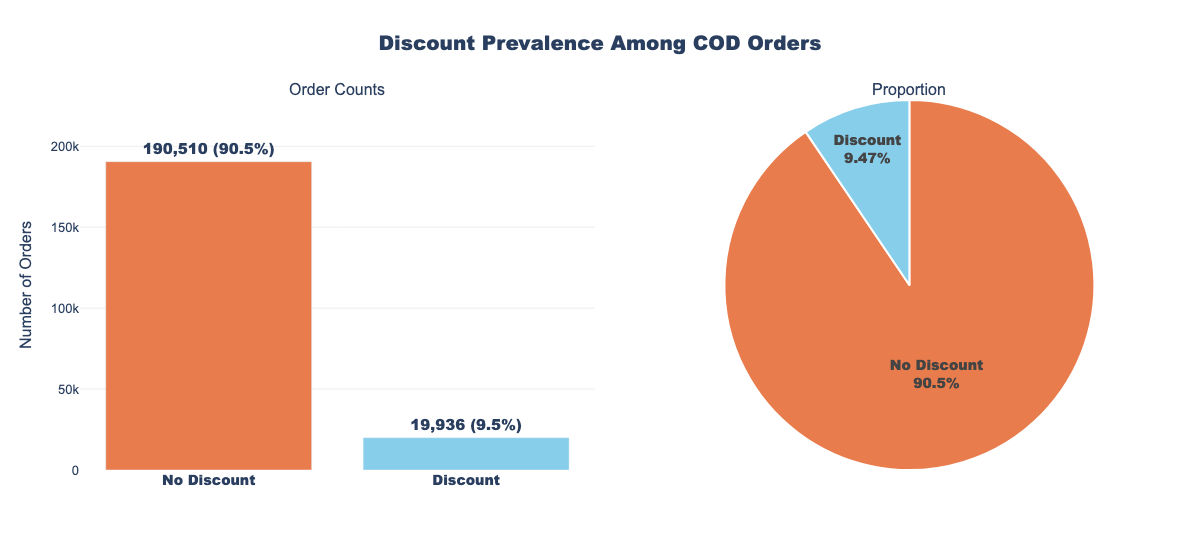

In [35]:
from plotly.subplots import make_subplots

disc_counts = data['has_discount'].value_counts()
labels = ['No Discount', 'Discount']
colors = ['#e97c4c', 'skyblue']

fig1 = make_subplots(rows=1, cols=2,
                     specs=[[{"type": "bar"}, {"type": "pie"}]],
                     subplot_titles=('Order Counts', 'Proportion'),
                     column_widths=[0.55, 0.45])

# Bar chart
fig1.add_trace(
    go.Bar(x=labels, y=disc_counts.values, marker_color=colors,
           text=[f'{v:,} ({v/len(data)*100:.1f}%)' for v in disc_counts.values],
           textposition='outside',
           textfont=dict(size=15, family='Arial Black'),
           showlegend=False),
    row=1, col=1)

# Pie chart
fig1.add_trace(
    go.Pie(labels=labels, values=disc_counts.values,
           marker=dict(colors=colors, line=dict(color='white', width=2)),
           textinfo='label+percent',
           textfont=dict(size=14, family='Arial Black'),
           hole=0,
           showlegend=False),
    row=1, col=2)

fig1.update_layout(
    height=550, width=1200,
    title_text='Discount Prevalence Among COD Orders',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13))

fig1.update_yaxes(title_text='Number of Orders', gridcolor='#EEEEEE',
                  range=[0, disc_counts.max() * 1.2], row=1, col=1)
fig1.update_xaxes(tickfont=dict(size=14, family='Arial Black'), row=1, col=1)

fig1.show()

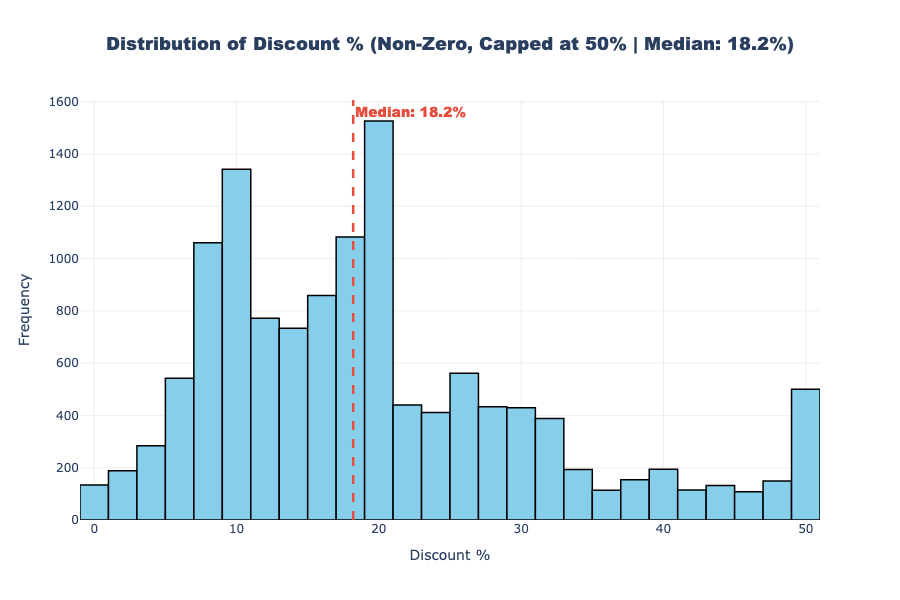

In [36]:
# Plot 2: Discount % Distribution (Non-Zero, Capped at 50%)
disc_pct_nonzero = data[(data['discount_pct'] > 0) & (data['discount_pct'] <= 50)]['discount_pct']
median_disc = disc_pct_nonzero.median()

fig2 = px.histogram(disc_pct_nonzero, x='discount_pct',
                    height=600, width=900,
                    title=f'Distribution of Discount % (Non-Zero, Capped at 50% | Median: {median_disc:.1f}%)',
                    labels={'discount_pct': 'Discount %', 'count': 'Frequency'},
                    nbins=25)

fig2.update_traces(
    marker_color='skyblue',
    marker_line_color='black',
    marker_line_width=1.5)

fig2.add_vline(x=median_disc, line_dash='dash', line_color='#e74c3c',
               line_width=2.5,
               annotation_text=f'Median: {median_disc:.1f}%',
               annotation_font=dict(size=14, color='#e74c3c', family='Arial Black'),
               annotation_position='top right')

fig2.update_layout(
    title_x=0.5,
    title_font=dict(size=18, family='Arial Black'),
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#EEEEEE'),
    yaxis=dict(title='Frequency', gridcolor='#EEEEEE'))

fig2.show()

### Monthly Volume

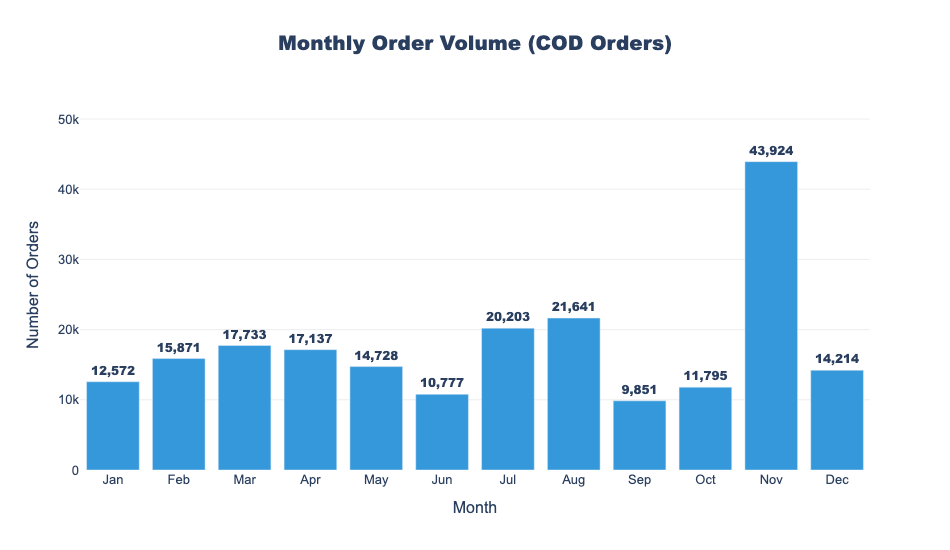

In [37]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = data['Month'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(
    go.Bar(x=month_names, y=monthly.values,
           marker_color='#3498db',
           text=[f'{v:,}' for v in monthly.values],
           textposition='outside',
           textfont=dict(size=12, family='Arial Black')))

fig.update_layout(
    height=550, width=950,
    title_text='Monthly Order Volume (COD Orders)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, monthly.max() * 1.2]),
    xaxis=dict(title='Month', tickfont=dict(size=13)))

fig.show()

### Quantity distribution

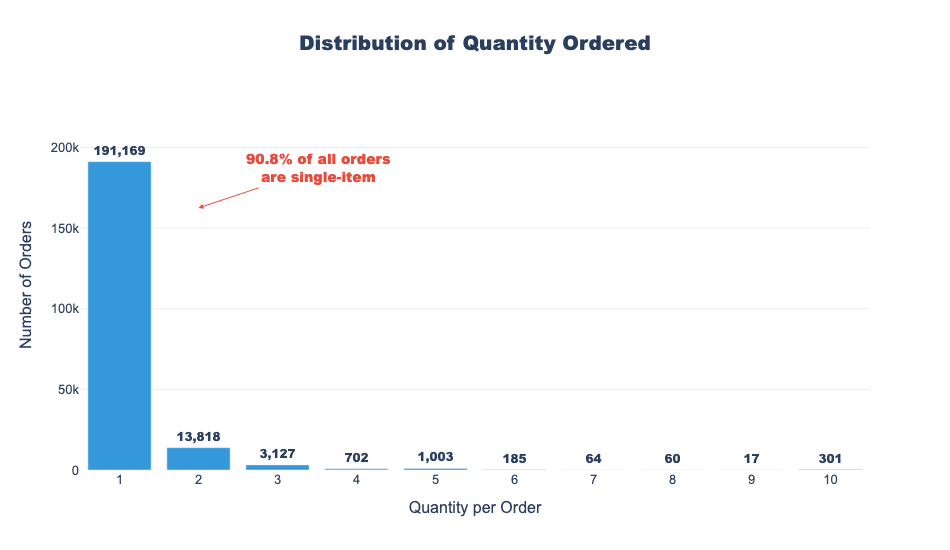

In [38]:
qty_counts = data['qty_ordered'].clip(upper=10).value_counts().sort_index()
pct_one = (data['qty_ordered'] == 1).mean() * 100

fig = go.Figure()
fig.add_trace(
    go.Bar(x=qty_counts.index.astype(int).astype(str),
           y=qty_counts.values,
           marker_color='#3498db',
           text=[f'{v:,}' for v in qty_counts.values],
           textposition='outside',
           textfont=dict(size=12, family='Arial Black')))

fig.add_annotation(
    x='1', y=qty_counts.iloc[0] * 0.85,
    text=f'{pct_one:.1f}% of all orders<br>are single-item',
    showarrow=True, arrowhead=2, arrowcolor='#e74c3c',
    font=dict(size=14, color='#e74c3c', family='Arial Black'),
    ax=120, ay=-40)

fig.update_layout(
    height=550, width=950,
    title_text='Distribution of Quantity Ordered',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, qty_counts.max() * 1.2]),
    xaxis=dict(title='Quantity per Order'))

fig.show()

#### Most orders per line items are single-unit purchases (90.9%). 

#### A small spike at quantity 10 (304 orders) likely represents bulk or reseller purchases. 

#### Given the low variance, this feature holds less predictive value. 

# Yearly trend

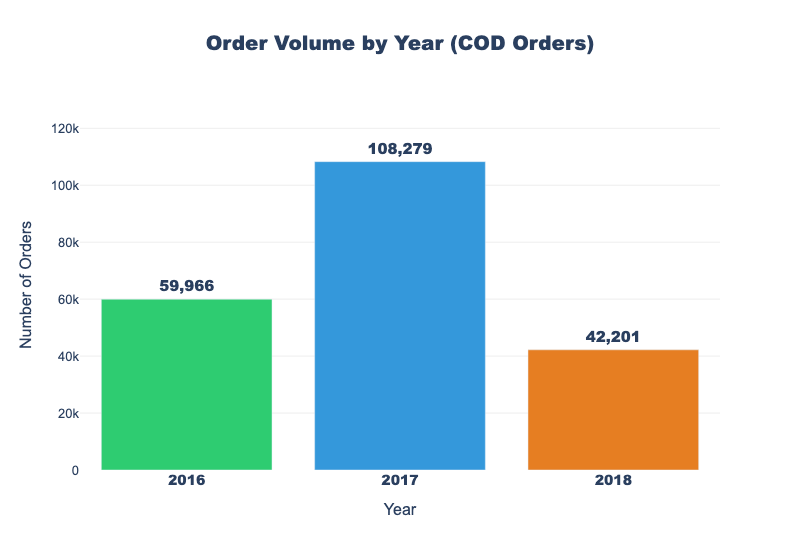

In [39]:
yearly = data['Year'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(
    go.Bar(x=yearly.index.astype(int).astype(str),
           y=yearly.values,
           marker_color=['#2ecc71', '#3498db', '#e67e22'],
           text=[f'{v:,}' for v in yearly.values],
           textposition='outside',
           textfont=dict(size=15, family='Arial Black')))

fig.update_layout(
    height=550, width=800,
    title_text='Order Volume by Year (COD Orders)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, yearly.max() * 1.2]),
    xaxis=dict(title='Year', tickfont=dict(size=14, family='Arial Black')))

fig.show()

## Weekly Analysis (Which days are most popular for online shopping?)

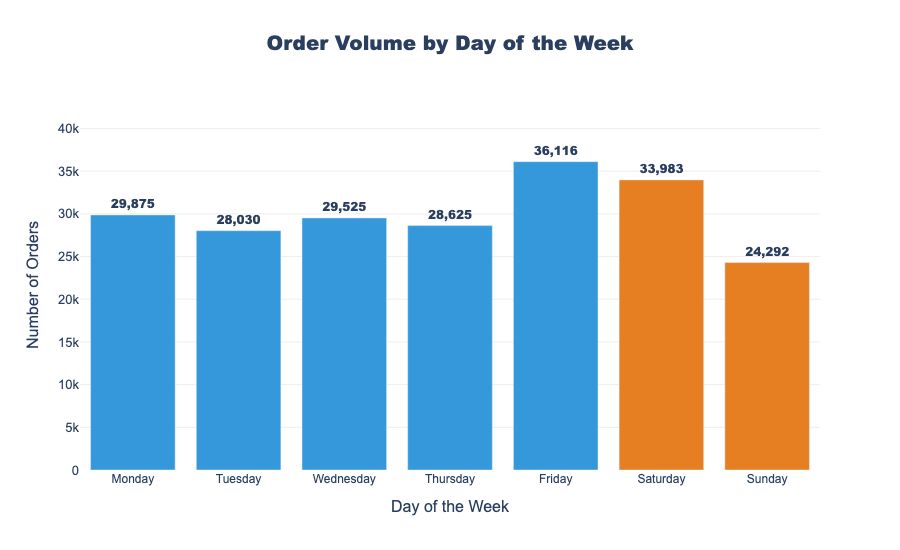

In [40]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = data['day_name'].value_counts().reindex(day_order)

colors = ['#3498db'] * 5 + ['#e67e22'] * 2

fig = go.Figure()
fig.add_trace(
    go.Bar(x=day_order, y=daily.values,
           marker_color=colors,
           text=[f'{v:,}' for v in daily.values],
           textposition='outside',
           textfont=dict(size=12, family='Arial Black')))

fig.update_layout(
    height=550, width=900,
    title_text='Order Volume by Day of the Week',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, daily.max() * 1.2]),
    xaxis=dict(title='Day of the Week', tickfont=dict(size=12)))

fig.show()

## Repeat v/s One-Time Customer

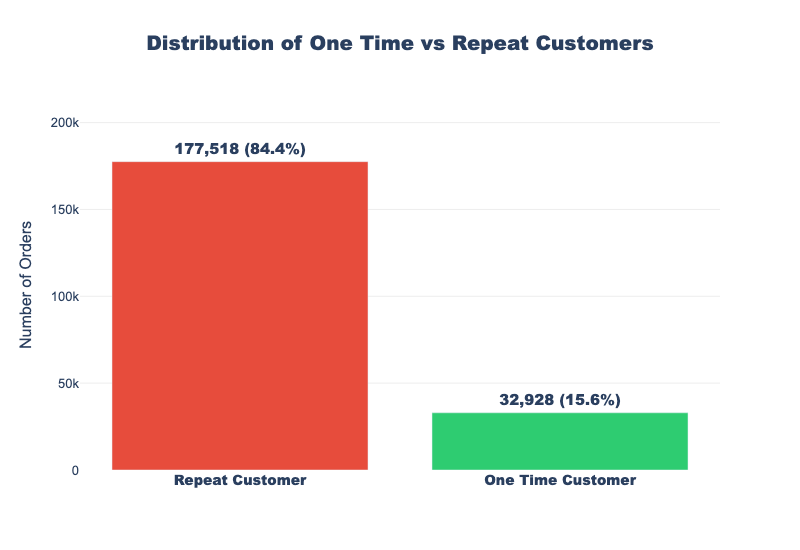

In [41]:
customer_orders = data.groupby('Customer ID').size()
data['is_repeat'] = data['Customer ID'].map(lambda x: 'Repeat Customer' if customer_orders[x] > 1 else 'One Time Customer')

labels = ['One Time Customer', 'Repeat Customer']

repeat_counts = data['is_repeat'].value_counts()
colors = ['#e74c3c', '#2ecc71']

fig = go.Figure()
fig.add_trace(
    go.Bar(x=repeat_counts.index, y=repeat_counts.values,
           marker_color=colors,
           text=[f'{v:,} ({v/len(data)*100:.1f}%)' for v in repeat_counts.values],
           textposition='outside',
           textfont=dict(size=15, family='Arial Black')))

fig.update_layout(
    height=550, width=800,
    title_text='Distribution of One Time vs Repeat Customers',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Number of Orders', gridcolor='#EEEEEE',
               range=[0, repeat_counts.max() * 1.2]),
    xaxis=dict(tickfont=dict(size=14, family='Arial Black')))

fig.show()

# Bivariate Analysis

## cancellation rate by product category

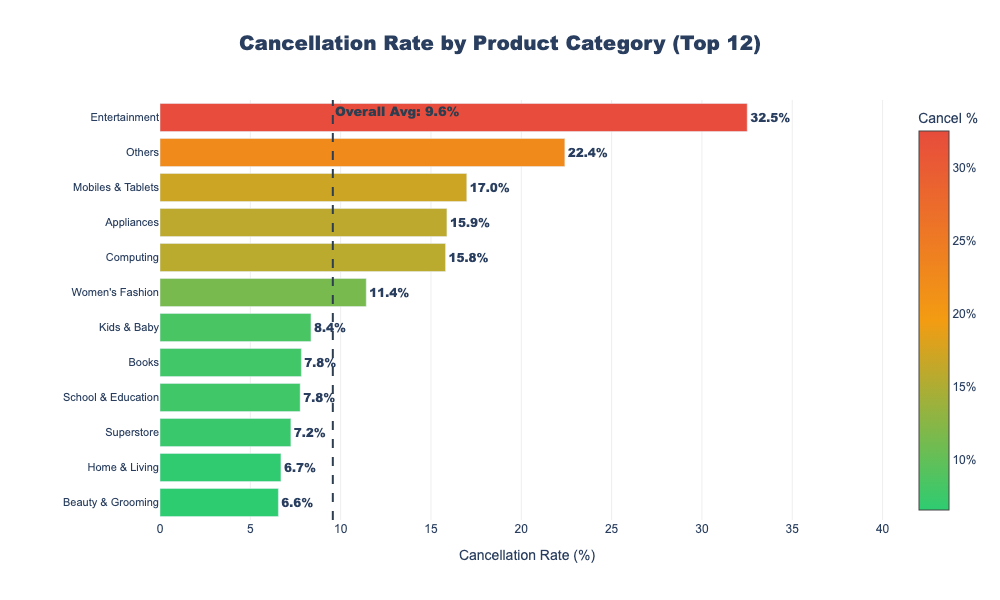

In [42]:
cat_cancel = (
    data.groupby('category_name_1')['status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .reset_index()
    .rename(columns={'status': 'cancellation_rate'})
)
cat_cancel = cat_cancel.sort_values('cancellation_rate', ascending=True).tail(12)


cat_volume = data['category_name_1'].value_counts()

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=cat_cancel['category_name_1'],
        x=cat_cancel['cancellation_rate'],
        orientation='h',
        marker=dict(
            color=cat_cancel['cancellation_rate'],
            colorscale=[[0, '#2ecc71'], [0.5, '#f39c12'], [1, '#e74c3c']],
            showscale=True,
            colorbar=dict(title='Cancel %', ticksuffix='%')
        ),
        text=[f"{v:.1f}%" for v in cat_cancel['cancellation_rate']],
        textposition='outside',
        textfont=dict(size=12, family='Arial Black')
    )
)

# Calculating Overall average Cancellation Rate to serve as a threshold
overall_cancel_rate = (data['status'] == 'Cancelled').mean() * 100
fig.add_vline(
    x=overall_cancel_rate,
    line_dash='dash',
    line_color='#2c3e50',
    line_width=2,
    annotation_text=f'Overall Avg: {overall_cancel_rate:.1f}%',
    annotation_font=dict(size=13, color='#2c3e50', family='Arial Black'),
    annotation_position='top right'
)

fig.update_layout(
    height=600, width=1000,
    title_text='Cancellation Rate by Product Category (Top 12)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(title='Cancellation Rate (%)', gridcolor='#EEEEEE', range=[0, cat_cancel['cancellation_rate'].max() * 1.25]),
    yaxis=dict(tickfont=dict(size=11)),
    margin=dict(l=160)
)

fig.show()


## Cancellation rate by price bracket

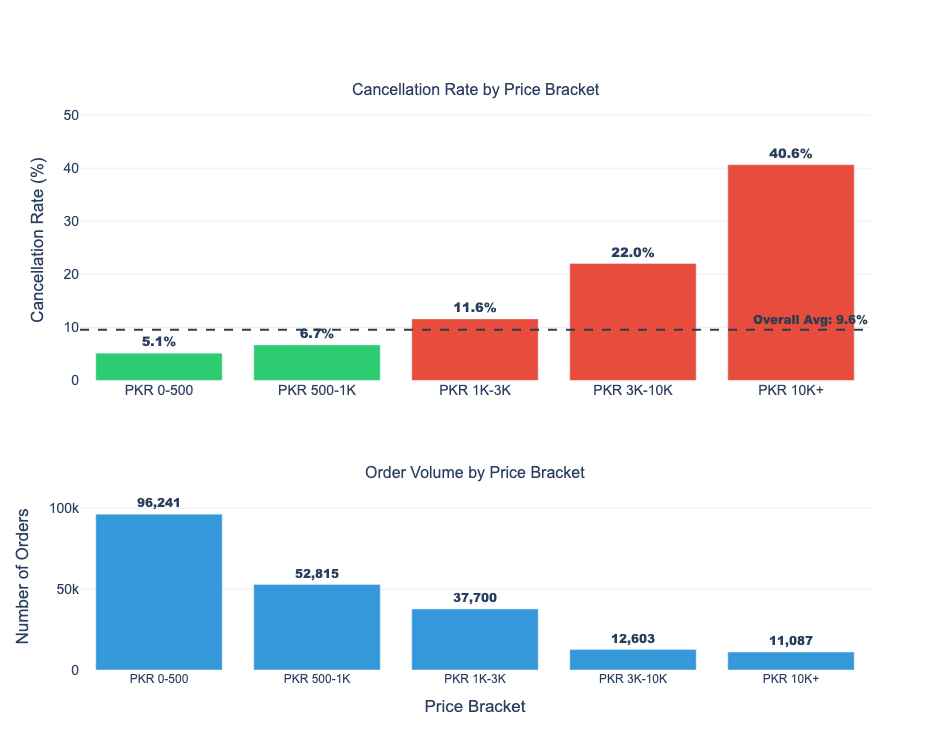

In [43]:
price_cancel = (
    data.groupby('price_bracket', observed=True)['status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .reset_index()
    .rename(columns={'status': 'cancellation_rate'})
)

price_volume = (
    data.groupby('price_bracket', observed=True)
    .size()
    .reset_index(name='volume')
)

price_summary = price_cancel.merge(price_volume, on='price_bracket')

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Cancellation Rate by Price Bracket', 'Order Volume by Price Bracket'),
    vertical_spacing=0.18,
    row_heights=[0.6, 0.4]
)

# Top Bar Chart: Cancellation rate based on price-bracket
fig.add_trace(
    go.Bar(
        x=price_summary['price_bracket'].astype(str),
        y=price_summary['cancellation_rate'],
        marker_color=['#2ecc71' if v < overall_cancel_rate else '#e74c3c'
                      for v in price_summary['cancellation_rate']],
        text=[f"{v:.1f}%" for v in price_summary['cancellation_rate']],
        textposition='outside',
        textfont=dict(size=13, family='Arial Black'),
        showlegend=False
    ),
    row=1, col=1
)

fig.add_hline(
    y=overall_cancel_rate,
    line_dash='dash',
    line_color='#2c3e50',
    line_width=2,
    annotation_text=f'Overall Avg: {overall_cancel_rate:.1f}%',
    annotation_font=dict(size=12, color='#2c3e50', family='Arial Black'),
    row=1, col=1
)

# Bottom Bar Chart: Showing total volume count as per different price-brackets
fig.add_trace(
    go.Bar(
        x=price_summary['price_bracket'].astype(str),
        y=price_summary['volume'],
        marker_color='#3498db',
        text=[f'{v:,}' for v in price_summary['volume']],
        textposition='outside',
        textfont=dict(size=12, family='Arial Black'),
        showlegend=False
    ),
    row=2, col=1
)

fig.update_layout(
    height=750, width=950,
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=14)
)

fig.update_yaxes(title_text='Cancellation Rate (%)', gridcolor='#EEEEEE',
                 range=[0, price_summary['cancellation_rate'].max() * 1.3], row=1, col=1)
fig.update_yaxes(title_text='Number of Orders', gridcolor='#EEEEEE',
                 range=[0, price_summary['volume'].max() * 1.2], row=2, col=1)
fig.update_xaxes(title_text='Price Bracket', tickfont=dict(size=12), row=2, col=1)

fig.show()

## Cancellation Rate by Discount

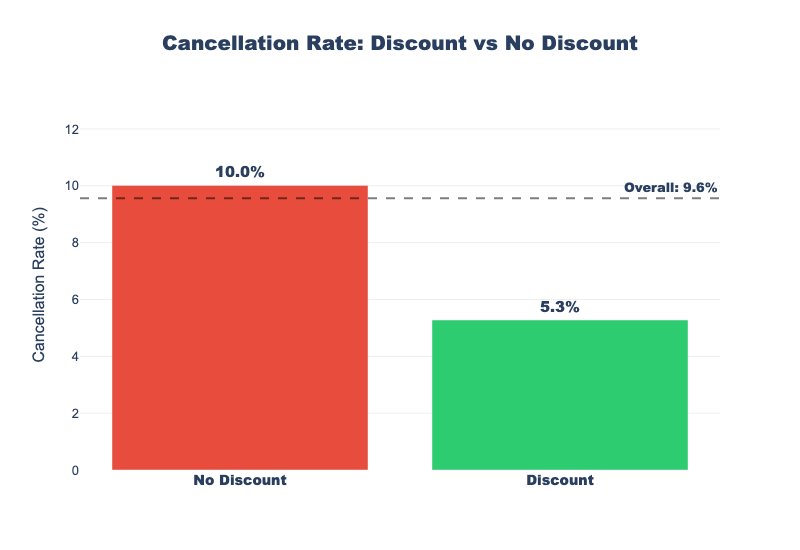

In [44]:
disc_cancel = data.groupby('has_discount')['status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100)
overall_rate = (data['status'] == 'Cancelled').mean() * 100

labels = ['No Discount', 'Discount']
colors = ['#e74c3c' if v > overall_rate else '#2ecc71' for v in disc_cancel.values]

fig = go.Figure()
fig.add_trace(
    go.Bar(x=labels, y=disc_cancel.values,
           marker_color=colors,
           text=[f'{v:.1f}%' for v in disc_cancel.values],
           textposition='outside',
           textfont=dict(size=15, family='Arial Black')))

fig.add_hline(y=overall_rate, line_dash='dash', line_color='black',
              line_width=2, opacity=0.5,
              annotation_text=f'Overall: {overall_rate:.1f}%',
              annotation_font=dict(size=13, family='Arial Black'),
              annotation_position='top right')

fig.update_layout(
    height=550, width=800,
    title_text='Cancellation Rate: Discount vs No Discount',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Cancellation Rate (%)', gridcolor='#EEEEEE',
               range=[0, disc_cancel.max() * 1.3]),
    xaxis=dict(tickfont=dict(size=14, family='Arial Black')))

fig.show()

### Order Status against Repeat and One-time Customer

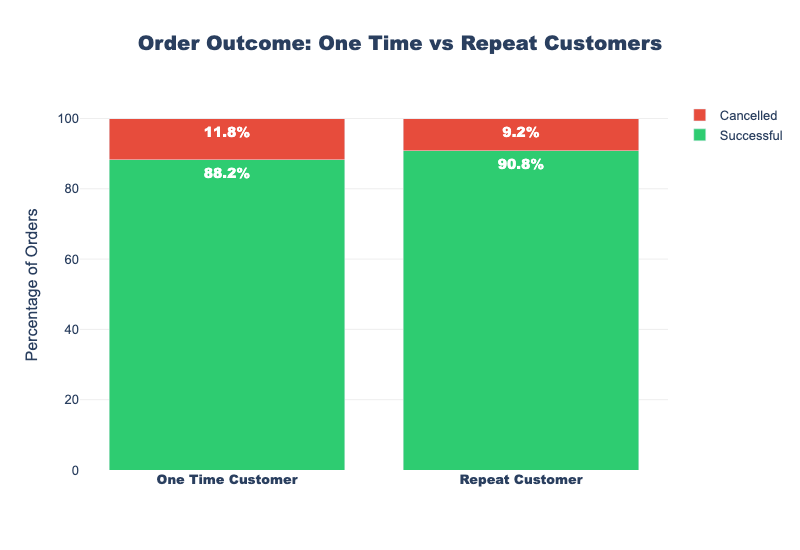

In [45]:

labels = ['One Time Customer', 'Repeat Customer']

first = data[data['is_repeat'] == 'One Time Customer']['status'].value_counts()
repeat = data[data['is_repeat'] == 'Repeat Customer']['status'].value_counts()

first_pct = first / first.sum() * 100
repeat_pct = repeat / repeat.sum() * 100

fig = go.Figure()

fig.add_trace(
    go.Bar(x=labels,
           y=[first_pct['Successful'], repeat_pct['Successful']],
           name='Successful',
           marker_color='#2ecc71',
           text=[f"{first_pct['Successful']:.1f}%", f"{repeat_pct['Successful']:.1f}%"],
           textposition='inside',
           textfont=dict(size=14, family='Arial Black', color='white')))

fig.add_trace(
    go.Bar(x=labels,
           y=[first_pct['Cancelled'], repeat_pct['Cancelled']],
           name='Cancelled',
           marker_color='#e74c3c',
           text=[f"{first_pct['Cancelled']:.1f}%", f"{repeat_pct['Cancelled']:.1f}%"],
           textposition='inside',
           textfont=dict(size=14, family='Arial Black', color='white')))

fig.update_layout(
    barmode='stack',
    height=550, width=800,
    title_text='Order Outcome: One Time vs Repeat Customers',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Percentage of Orders', gridcolor='#EEEEEE'),
    xaxis=dict(tickfont=dict(size=13, family='Arial Black')),
    legend=dict(font=dict(size=13)))

fig.show()

In [46]:
data.columns.unique

<bound method Index.unique of Index(['status', 'sku', 'price', 'qty_ordered', 'category_name_1',
       'discount_amount', 'Year', 'Month', 'Customer ID', 'item_total',
       'day_of_week', 'is_weekend', 'discount_pct', 'has_discount',
       'price_bracket', 'day_name', 'is_repeat'],
      dtype='object')>

## Cancellation Rate by Month

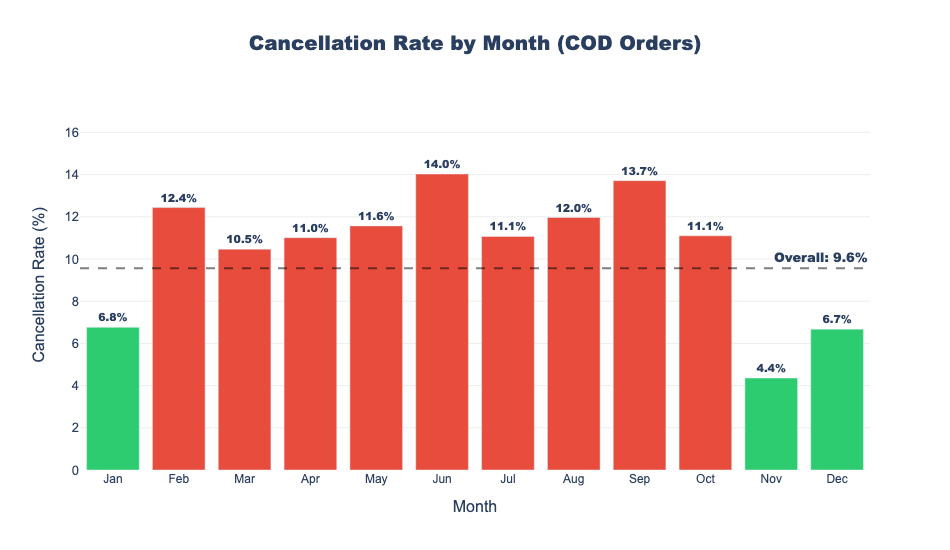

In [47]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_cancel = data.groupby('Month')['status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100).sort_index()
overall_rate = (data['status'] == 'Cancelled').mean() * 100

colors = ['#e74c3c' if v > overall_rate else '#2ecc71' for v in monthly_cancel.values]

fig = go.Figure()
fig.add_trace(
    go.Bar(x=month_names, y=monthly_cancel.values,
           marker_color=colors,
           text=[f'{v:.1f}%' for v in monthly_cancel.values],
           textposition='outside',
           textfont=dict(size=11, family='Arial Black')))

fig.add_hline(y=overall_rate, line_dash='dash', line_color='black',
              line_width=2, opacity=0.5,
              annotation_text=f'Overall: {overall_rate:.1f}%',
              annotation_font=dict(size=13, family='Arial Black'),
              annotation_position='top right')

fig.update_layout(
    height=550, width=950,
    title_text='Cancellation Rate by Month (COD Orders)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Cancellation Rate (%)', gridcolor='#EEEEEE',
               range=[0, monthly_cancel.max() * 1.25]),
    xaxis=dict(title='Month', tickfont=dict(size=12)))

fig.show()

## Cancellation rate by Day of the Week

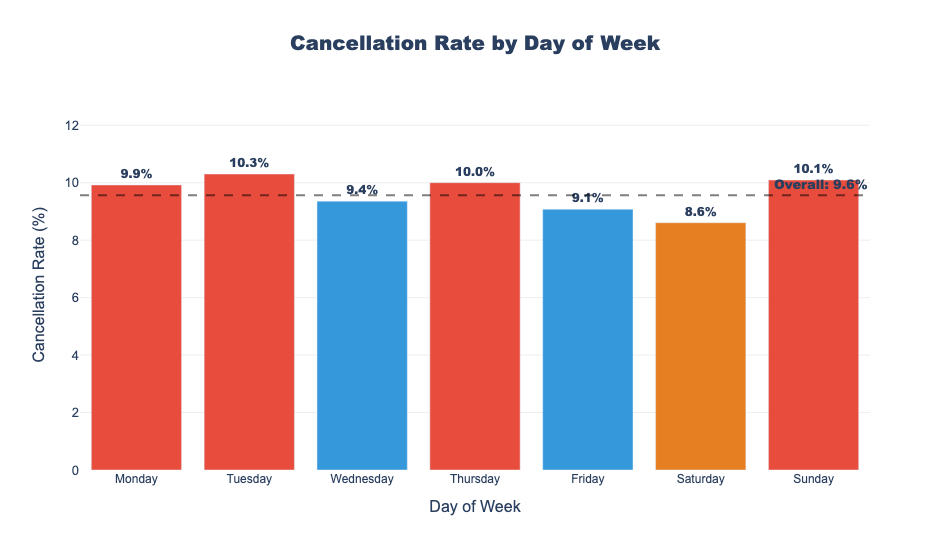

In [48]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_cancel = data.groupby('day_name')['status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100).reindex(day_order)
overall_rate = (data['status'] == 'Cancelled').mean() * 100

colors = ['#3498db'] * 5 + ['#e67e22'] * 2
colors = ['#e74c3c' if v > overall_rate else c for v, c in zip(daily_cancel.values, colors)]

fig = go.Figure()
fig.add_trace(
    go.Bar(x=day_order, y=daily_cancel.values,
           marker_color=colors,
           text=[f'{v:.1f}%' for v in daily_cancel.values],
           textposition='outside',
           textfont=dict(size=12, family='Arial Black')))

fig.add_hline(y=overall_rate, line_dash='dash', line_color='black',
              line_width=2, opacity=0.5,
              annotation_text=f'Overall: {overall_rate:.1f}%',
              annotation_font=dict(size=13, family='Arial Black'),
              annotation_position='top right')

fig.update_layout(
    height=550, width=950,
    title_text='Cancellation Rate by Day of Week',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Cancellation Rate (%)', gridcolor='#EEEEEE',
               range=[0, daily_cancel.max() * 1.25]),
    xaxis=dict(title='Day of Week', tickfont=dict(size=12)))

fig.show()

## Cancellation Rate by Year

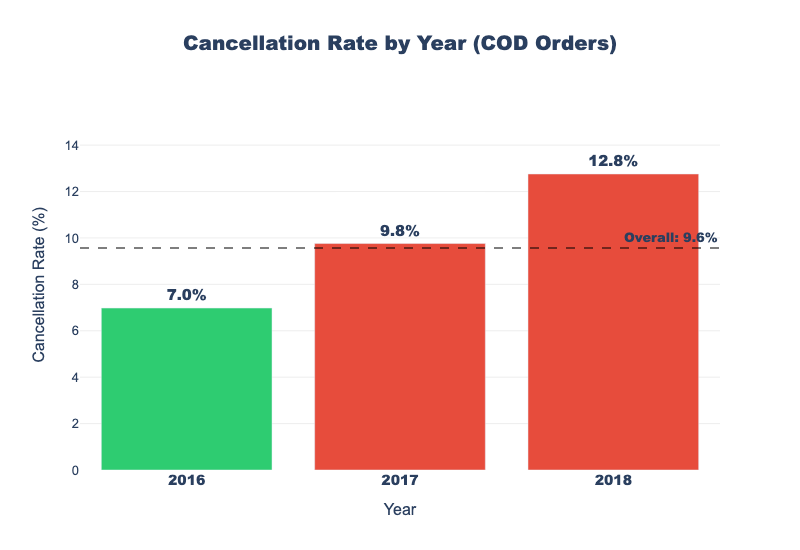

In [49]:
yearly_cancel = data.groupby('Year')['status'].apply(
    lambda x: (x == 'Cancelled').mean() * 100).sort_index()
overall_rate = (data['status'] == 'Cancelled').mean() * 100

colors = ['#2ecc71' if v < overall_rate else '#e74c3c' for v in yearly_cancel.values]

fig = go.Figure()
fig.add_trace(
    go.Bar(x=yearly_cancel.index.astype(int).astype(str),
           y=yearly_cancel.values,
           marker_color=colors,
           text=[f'{v:.1f}%' for v in yearly_cancel.values],
           textposition='outside',
           textfont=dict(size=15, family='Arial Black')))

fig.add_hline(y=overall_rate, line_dash='dash', line_color='black',
              line_width=2, opacity=0.5,
              annotation_text=f'Overall: {overall_rate:.1f}%',
              annotation_font=dict(size=13, family='Arial Black'),
              annotation_position='top right')

fig.update_layout(
    height=550, width=800,
    title_text='Cancellation Rate by Year (COD Orders)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(title='Cancellation Rate (%)', gridcolor='#EEEEEE',
               range=[0, yearly_cancel.max() * 1.25]),
    xaxis=dict(title='Year', tickfont=dict(size=14, family='Arial Black')))

fig.show()

## Correlation HeatMap

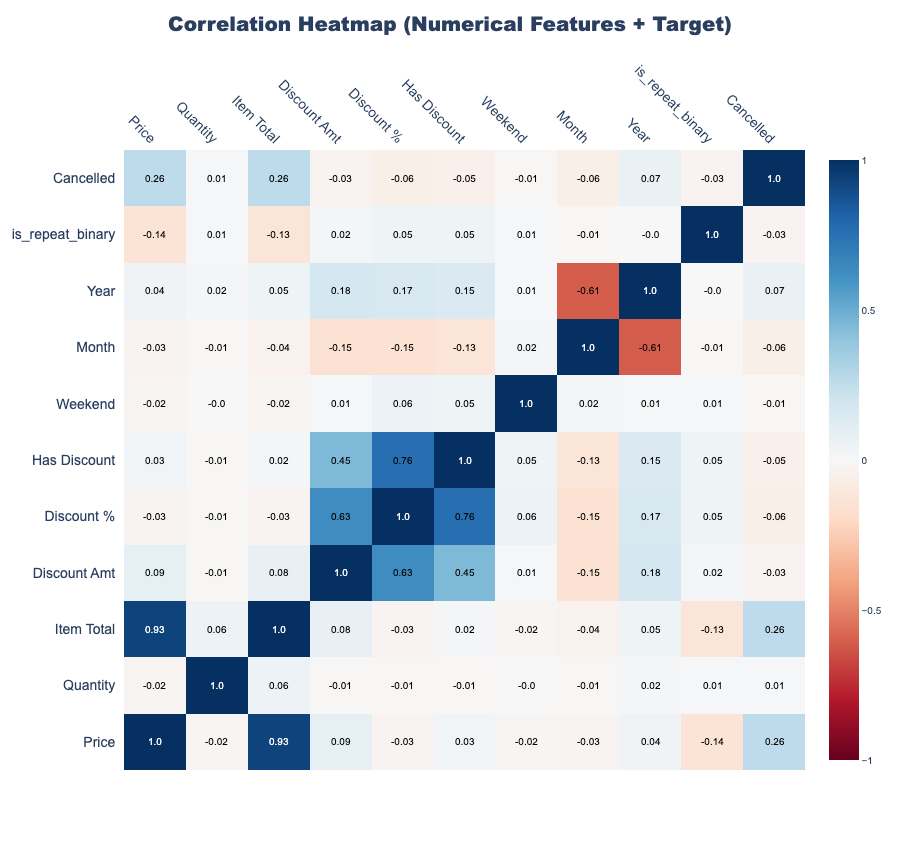

In [50]:
import plotly.figure_factory as ff

# Encode target as binary for correlation
data['status_binary'] = (data['status'] == 'Cancelled').astype(int)
data['is_repeat_binary'] = (data['is_repeat'] == 'Repeat Customer').astype(int)

corr_cols = ['price', 'qty_ordered', 'item_total', 'discount_amount',
             'discount_pct', 'has_discount', 'is_weekend',
             'Month', 'Year', 'is_repeat_binary', 'status_binary']

corr_matrix = data[corr_cols].corr().round(2)

# Rename for readability
rename = {
    'price': 'Price',
    'qty_ordered': 'Quantity',
    'item_total': 'Item Total',
    'discount_amount': 'Discount Amt',
    'discount_pct': 'Discount %',
    'tenure_days': 'Tenure',
    'has_discount': 'Has Discount',
    'is_weekend': 'Weekend',
    'Month': 'Month',
    'Year': 'Year',
    'status_binary': 'Cancelled'
}
corr_matrix = corr_matrix.rename(index=rename, columns=rename)

fig = ff.create_annotated_heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    annotation_text=corr_matrix.values.astype(str),
    colorscale='RdBu',
    showscale=True,
    zmid=0,
    zmin=-1,
    zmax=1)

for i in range(len(fig.layout.annotations)):
    val = float(fig.layout.annotations[i].text)
    if abs(val) >= 0.8:
        fig.layout.annotations[i].font.color = 'white'
    else:
        fig.layout.annotations[i].font.color = 'black'

fig.update_layout(
    height=850, width=900,
    title_text='Correlation Heatmap (Numerical Features + Target)',
    title_font=dict(size=20, family='Arial Black'),
    title_x=0.5,
    title_y=0.98,
    paper_bgcolor='white',
    font=dict(family='Arial', size=10),
    xaxis=dict(tickangle=45, tickfont=dict(size=14)),
    yaxis=dict(tickfont=dict(size=14)),
    margin=dict(t=150, l=120))

fig.show()

# Drop the temporary column
data = data.drop(columns=['status_binary'])
data = data.drop(columns=['is_repeat_binary'])